In [1]:
import csv
import re
import os
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from datasets import Dataset, DatasetDict


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#%% Load and prepare data
dataset_raw = pd.read_csv('Data/Product_Normalization_GRI.csv')
normalized_product_attributes = pd.read_excel('Data/Normalized_product_attribute_name.xlsx', sheet_name='Normalized Product Attributes')


In [3]:
#%% Loading Preprocessed (Expanded) Dataset
dataset_raw_expanded = pd.read_csv('Data/Product_Normalization_GRI_Expanded.csv')

In [4]:
descriptions = dataset_raw_expanded['Room Description Expanded'].unique()

In [11]:
len(dataset_raw_expanded)

31237

In [7]:
dataset_raw_expanded = dataset_raw_expanded.drop_duplicates(subset=['Room Description Expanded'])


In [ ]:
dataset_raw_expanded[dataset_raw_expanded['Guest Room Info'] == 'Bungalow']

,Unnamed: 0,Room Description,Guest Room Info,Room Description Expanded
13000,13000,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW APPROXI...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW APPROXI...
13001,13001,OUR BEST AVAILABLE RATE|2 BDRM BUNGALOW HOME -...,Bungalow,OUR BEST AVAILABLE RATE|2 BDRM BUNGALOW HOME -...
13006,13006,SPA REJUVENATION PACKAGE|2 BDRM BUNGALOW HOME ...,Bungalow,SPA REJUVENATION PACKAGE|2 BDRM BUNGALOW HOME ...
13008,13008,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...
13009,13009,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...
...,...,...,...,...
13995,13995,ULTIMATE STAYCATION|BEVERLY HILLS BUNGALOW SUI...,Bungalow,ULTIMATE STAYCATION|BEVERLY HILLS BUNGALOW SUI...
13996,13996,SIGNATURE TRAVEL NET|END OF PONTOON OVERWATER ...,Bungalow,SIGNATURE TRAVEL NET|END OF PONTOON OVERWATER ...
13997,13997,BEST AVAILABLE RATE|533 SQ. FT. VINEYARD MURPH...,Bungalow,BEST AVAILABLE RATE|533 SQ. FT. VINEYARD MURPH...
13998,13998,AMEX GBT GHP RATE|OCEAN COASTAL BUNGALOW SUITE...,Bungalow,AMEX GBT GHP RATE|OCEAN COASTAL BUNGALOW SUITE...


In [10]:
dataset_raw_expanded[dataset_raw_expanded.isnull().any(axis=1)]
#dataset_raw_expanded = dataset_raw_expanded.fillna('Bungalow')

,Unnamed: 0,Room Description,Guest Room Info,Room Description Expanded


In [12]:
normalized_product_attributes

,BedType,OTA TYPE = BED,Unnamed: 2,RoomType,OTA TYPE = GRI,Unnamed: 5,Rateplan Incl/Value-adds,OTA TYPE = HAC,Unnamed: 8,Room Amenities,OTA TYPE = RMA,Unnamed: 11,Mealplan,OTA TYPE = MPT,Unnamed: 14,RoomView,OTA TYPE = RVT,Unnamed: 17,Taxes & Fees,OTA TYPE = FTT
0,Double/Full Bed,1.0,NaN,Accessible Room,1.0,NaN,Piano,0,NaN,Adjoining rooms,1.0,NaN,All Inclusive,1.0,NaN,Airport view,1.0,NaN,Bed tax,1.0
1,Futon Bed,2.0,NaN,Suite,3.0,NaN,24-hour front desk,1,NaN,Air conditioning,2.0,NaN,Full Board or American,2.0,NaN,Bay view,2.0,NaN,City hotel fee,2.0
2,King Bed,3.0,NaN,Executive/Club Suite,6.0,NaN,24-hour room service,2,NaN,Alarm clock,3.0,NaN,Buffet Breakfast,4.0,NaN,City view,3.0,NaN,PropertyFee,2.0
3,Murphy Bed,4.0,NaN,Double Room,10.0,NaN,24-hour security,3,NaN,All news channel,4.0,NaN,Continental Breakfast,6.0,NaN,Courtyard view,4.0,NaN,City tax,3.0
4,Queen Bed,5.0,NaN,King Bedroom,11.0,NaN,adjoining rooms,4,NaN,radio,5.0,NaN,Family Plan,9.0,NaN,Golf View,5.0,NaN,Municipal Tax,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,NaN,NaN,NaN,NaN,NaN,NaN,Train station shuttle services,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
378,NaN,NaN,NaN,NaN,NaN,NaN,Electric car charging stations,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
379,NaN,NaN,NaN,NaN,NaN,NaN,Golf clubs (equipments),2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
380,NaN,NaN,NaN,NaN,NaN,NaN,Beach club,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Get room types
room_types = normalized_product_attributes['RoomType'].dropna().unique()
room_types_list = room_types.tolist()

bed_types = normalized_product_attributes['BedType'].dropna().unique()
bed_types_list = bed_types.tolist()

room_amenities = normalized_product_attributes['Room Amenities'].dropna().unique()
room_amenities_list = room_amenities.tolist()

rateplan_types = normalized_product_attributes['Rateplan Incl/Value-adds'].dropna().unique()
rateplan_types_list = rateplan_types.tolist()

meal_plan = normalized_product_attributes['Mealplan'].dropna().unique()
meal_plan_list = meal_plan.tolist()

room_view = normalized_product_attributes['RoomView'].dropna().unique()
room_view_list = room_view.tolist()

taxes_view = normalized_product_attributes['Taxes & Fees'].dropna().unique()
taxes_view_list = taxes_view.tolist()



In [ ]:
room_types_stripped_list = []
for item in room_types_list:
    room_types_stripped_list.append(item.strip())

bed_types_stripped_list = []
for item in bed_types_list:
    bed_types_stripped_list.append(item.strip())

room_amenities_stripped_list = []
for item in room_amenities_list:
    room_amenities_stripped_list.append(item.strip())

In [18]:
dataset_raw_expanded['Room Description Expanded']

0        FLEXIBLE RATE|2QUEEN HEARING ACCESSIBLE STUDIO...
1        2X POINTS PACKAGE|2QUEEN HEARING ACCESSIBLE ST...
2        PARK AND STAY AAA|2QUEEN HEARING ACCESSIBLE ST...
3        PARK AND STAY AARP|2QUEEN HEARING ACCESSIBLE S...
4        PARK AND GO|2QUEEN HEARING ACCESSIBLE STUDIO S...
                               ...                        
34990    BEST FLEXIBLE RATE|PREMIUM OCEAN VIEW ROOM WHE...
34991    1000 BONUS POINTS NT INCLUDES|ROOM AND 1000 RE...
34992    BEST FLEXIBLE RATE|HOLIDAY INN EXPRESS ROOM WH...
34993    GREATRATE DISCOUNTED STAYS. 2|RUN OF HOUSE STA...
34995    CWT INCLUDES WIFI USE OF|FITNESS AND WELLNESS ...
Name: Room Description Expanded, Length: 31237, dtype: object

In [15]:
from gensim import corpora, models
import gensim

In [27]:
def apply_topic_modeling(descriptions, num_topics=50):
    """
    Apply LDA topic modeling on full descriptions
    """
    # 1. Preprocess
    texts = [
        gensim.utils.simple_preprocess(desc, deacc=True)
        for desc in descriptions
    ]
    
    # 2. Create dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    # 3. Train LDA model
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # 4. Get topics
    topics = lda_model.print_topics(num_words=10)
    
    return lda_model, dictionary, corpus, topics

In [ ]:
### n = 50
# Apply and analyze
lda_model, dictionary, corpus, topics = apply_topic_modeling(
dataset_raw_expanded['Room Description Expanded'],
num_topics=50  # Start with 50 topics
)

# Print topics
for idx, topic in topics:
    print(f"\nTopic {idx}:")
    print(topic)


Topic 38:
0.421*"views" + 0.100*"pref" + 0.074*"consortia" + 0.066*"has" + 0.049*"sale" + 0.043*"designed" + 0.041*"great" + 0.022*"upper" + 0.019*"lv" + 0.018*"bathrms"

Topic 16:
0.270*"aaa" + 0.093*"required" + 0.080*"rate" + 0.079*"caa" + 0.074*"membership" + 0.065*"card" + 0.047*"auto" + 0.045*"american" + 0.043*"confiden" + 0.043*"king"

Topic 13:
0.205*"discount" + 0.128*"senior" + 0.075*"aarp" + 0.062*"marriott" + 0.052*"side" + 0.052*"disc" + 0.050*"fl" + 0.038*"and" + 0.033*"mt" + 0.030*"id"

Topic 35:
0.211*"usd" + 0.147*"courtyard" + 0.116*"chg" + 0.086*"rsrt" + 0.074*"rc" + 0.050*"kng" + 0.044*"suites" + 0.037*"any" + 0.036*"consecutive" + 0.035*"lux"

Topic 37:
0.094*"tv" + 0.087*"flat" + 0.073*"air" + 0.065*"screen" + 0.059*"room" + 0.040*"free" + 0.033*"wireless" + 0.032*"conditioning" + 0.029*"in" + 0.027*"cable"

Topic 49:
0.119*"rate" + 0.110*"see" + 0.100*"details" + 0.074*"prepay" + 0.058*"refundable" + 0.055*"non" + 0.048*"stay" + 0.043*"to" + 0.038*"room" + 0.03

In [34]:
# Or save as CSV for better structure
import pandas as pd
all_topics = lda_model.show_topics(num_topics=50, num_words=10)
topics_df = pd.DataFrame([
    {
        'Topic_ID': idx,
        'Top_Words': topic
    } for idx, topic in all_topics
])

topics_df.to_csv('topic_analysis_50.csv', index=False)

In [36]:
import xlsxwriter

def format_topics(lda_model, num_topics=50, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(lda_model)

# Save to Excel with formatting
with pd.ExcelWriter('topic_analysis_50.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)

print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']].head())

Sample of readable format:
     Topic            Top 3 Words                      Interpretation
0  Topic 0         in, shower, th         Topic about: in, shower, th
1  Topic 1  premium, travel, wifi  Topic about: premium, travel, wifi
2  Topic 2            sq, ft, bed            Topic about: sq, ft, bed
3  Topic 3   executive, inc, with   Topic about: executive, inc, with
4  Topic 4          or, twin, sqm          Topic about: or, twin, sqm


In [37]:
### n = 240
# Apply and analyze
lda_model, dictionary, corpus, topics = apply_topic_modeling(
dataset_raw_expanded['Room Description Expanded'],
num_topics=240
)

# Print topics
for idx, topic in topics:
    print(f"\nTopic {idx}:")
    print(topic)


Topic 27:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 178:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 168:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 203:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 28:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 8:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing"

In [38]:
import xlsxwriter

def format_topics(lda_model, num_topics=240, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(lda_model)

# Save to Excel with formatting
with pd.ExcelWriter('topic_analysis_240_10.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)

print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']].head())

Sample of readable format:
     Topic          Top 3 Words                    Interpretation
0  Topic 0  pullout, qn, sofabd  Topic about: pullout, qn, sofabd
1  Topic 1     see, rules, rate     Topic about: see, rules, rate
2  Topic 2  flexible, rate, bed  Topic about: flexible, rate, bed
3  Topic 3       pts, max, free       Topic about: pts, max, free
4  Topic 4  check, required, at  Topic about: check, required, at


## Coherence Scores that guided n = 240 above

In [20]:
from gensim.models.coherencemodel import CoherenceModel

def analyze_coherence(texts, dictionary, model):
    """
    Calculate coherence score for LDA model
    Higher score = more interpretable topics
    """
    coherence_model = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'  # Using c_v metric
    )
    return coherence_model.get_coherence()

def find_optimal_topics(descriptions, start=10, limit=100, step=10):
    """
    Find optimal number of topics by coherence score
    """
    # Preprocess once
    texts = [gensim.utils.simple_preprocess(desc, deacc=True) for desc in descriptions]
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    coherence_scores = []
    
    for num_topics in range(start, limit, step):
        print(f"\nTesting {num_topics} topics...")
        
        # Train model
        lda = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10
        )
        
        # Calculate coherence
        coherence = analyze_coherence(texts, dictionary, lda)
        coherence_scores.append(coherence)
        print(f"Coherence score: {coherence}")
    
    # Plot results
    import matplotlib.pyplot as plt
    plt.plot(range(start, limit, step), coherence_scores)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score")
    plt.title("Topic Coherence Scores")
    plt.show()
    
    return coherence_scores



Testing 10 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3826158568392863

Testing 20 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3768384451849927

Testing 30 topics...


...

Coherence score: 0.38175589315312813

Testing 80 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3870840990669027

Testing 90 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.39627709509346964


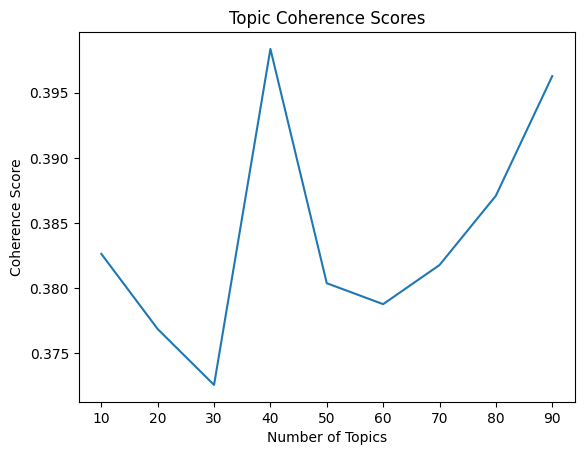

In [21]:
# Find optimal number of topics
scores = find_optimal_topics(
    dataset_raw_expanded['Room Description Expanded'],
    start=10,
    limit=100,
    step=10
)


Testing 100 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.4091654602020167

Testing 110 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.40704755926719793

Testing 120 topics...


...

Coherence score: 0.48318940273795424

Testing 230 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.49039943731678537

Testing 240 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.4924379182530552


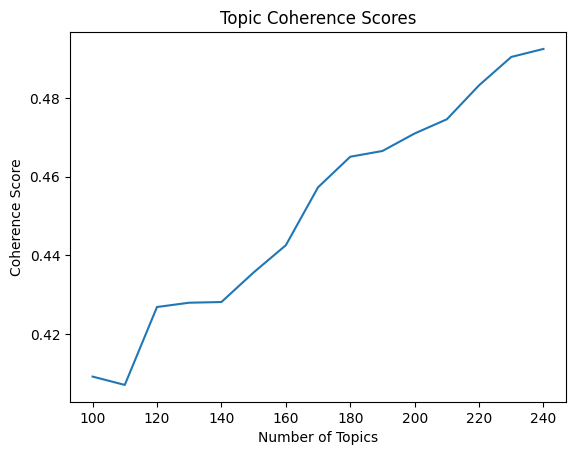

In [22]:
# Find optimal number of topics
scores_v2 = find_optimal_topics(
    dataset_raw_expanded['Room Description Expanded'],
    start=100,
    limit=250,
    step=10
)

## Guided LDA using attribute values

In [51]:
def create_guided_topics(attribute_lists):
    """
    Create seed topics from attribute lists
    
    attribute_lists = {
        'bed_types': bed_types_stripped_list,
        'room_amenities': room_amenities_stripped_list,
        'room_view': room_view_list,
        'meal_plan': meal_plan_list,
        # etc.
    }
    """
    seed_topics = {}
    for attr_name, values in attribute_lists.items():
        # Create seed words for each attribute value
        for value in values:
            # Split value into words
            words = value.lower().split()
            # Add related terms if needed
            seed_topics[f"{attr_name}_{value}"] = words
    
    return seed_topics

# Modified LDA with guided topics
def apply_guided_lda(descriptions, seed_topics, num_topics=None):
    """
    Apply LDA with seed topics from attributes
    """
    # If num_topics not specified, use number of seed topics
    if num_topics is None:
        num_topics = len(seed_topics)
    
    texts = [gensim.utils.simple_preprocess(desc, deacc=True) 
             for desc in descriptions]
    
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    # Create seed topic probability matrix
    seed_matrix = [[
        2.0 if word in topic_words else 0.0 
        for word in dictionary.token2id
    ] for topic_words in seed_topics.values()]
    
    # Train guided LDA
    model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        eta=seed_matrix  # Use seed topics
    )
    
    return model, dictionary, corpus

In [52]:
# Create attribute dictionary
attribute_lists = {
    #'bed_types': bed_types_stripped_list,
    #'room_amenities': room_amenities_stripped_list,
    #'room_view': room_view_list,
    'meal_plan': meal_plan_list
}

# Get seed topics
seed_topics = create_guided_topics(attribute_lists)

# Train guided model
guided_lda, dictionary, corpus = apply_guided_lda(
    dataset_raw_expanded['Room Description Expanded'],
    seed_topics
)

/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/gensim/models/ldamodel.py:1134: RuntimeWarning: invalid value encountered in multiply
  score += np.sum((self.eta - _lambda) * Elogbeta)
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/gensim/models/ldamodel.py:1135: RuntimeWarning: invalid value encountered in subtract
  score += np.sum(gammaln(_lambda) - gammaln(self.eta))


In [54]:
seed_topics

{'meal_plan_All Inclusive': ['all', 'inclusive'],
 'meal_plan_Full Board or American': ['full', 'board', 'or', 'american'],
 'meal_plan_Buffet Breakfast': ['buffet', 'breakfast'],
 'meal_plan_Continental Breakfast': ['continental', 'breakfast'],
 'meal_plan_Family Plan': ['family', 'plan'],
 'meal_plan_Full Board': ['full', 'board'],
 'meal_plan_Half Board or Modified American': ['half',
  'board',
  'or',
  'modified',
  'american'],
 'meal_plan_Room Only or European': ['room', 'only', 'or', 'european'],
 'meal_plan_Self Catering': ['self', 'catering'],
 'meal_plan_Breakfast and Dinner': ['breakfast', 'and', 'dinner'],
 'meal_plan_Breakfast ': ['breakfast'],
 'meal_plan_Lunch': ['lunch'],
 'meal_plan_Dinner': ['dinner'],
 'meal_plan_Breakfast and Lunch': ['breakfast', 'and', 'lunch'],
 'meal_plan_Lunch and Dinner': ['lunch', 'and', 'dinner']}

In [53]:
import xlsxwriter

def format_topics(lda_model, num_topics=15, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(guided_lda)

# Save to Excel with formatting
with pd.ExcelWriter('guided_topic_analysis_15.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)

print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']].head())

Sample of readable format:
     Topic            Top 3 Words                      Interpretation
0  Topic 0     king, view, luxury     Topic about: king, view, luxury
1  Topic 1        suite, free, wi        Topic about: suite, free, wi
2  Topic 2  queen, standard, room  Topic about: queen, standard, room
3  Topic 3  free, wifi, breakfast  Topic about: free, wifi, breakfast
4  Topic 4      rate, suite, king      Topic about: rate, suite, king


In [47]:
guided_lda.show_topics(num_topics=-1,
    num_words=10,
    formatted=True)

[(0,
  '0.067*"king" + 0.063*"view" + 0.055*"luxury" + 0.042*"sqm" + 0.042*"floor" + 0.034*"room" + 0.034*"suite" + 0.033*"wifi" + 0.028*"bed" + 0.026*"shower"'),
 (1,
  '0.100*"suite" + 0.049*"free" + 0.048*"wi" + 0.048*"fi" + 0.048*"king" + 0.040*"premium" + 0.040*"wifi" + 0.038*"luxury" + 0.033*"bed" + 0.031*"kitchen"'),
 (2,
  '0.082*"queen" + 0.078*"standard" + 0.073*"room" + 0.063*"rate" + 0.048*"beds" + 0.048*"bed" + 0.039*"in" + 0.038*"government" + 0.034*"global" + 0.032*"at"'),
 (3,
  '0.107*"free" + 0.093*"wifi" + 0.049*"breakfast" + 0.047*"room" + 0.046*"bed" + 0.041*"rate" + 0.037*"sqm" + 0.022*"minibar" + 0.021*"king" + 0.021*"incl"'),
 (4,
  '0.108*"rate" + 0.093*"suite" + 0.065*"king" + 0.040*"flexible" + 0.037*"presidential" + 0.037*"bedroom" + 0.034*"view" + 0.028*"room" + 0.026*"bed" + 0.023*"aaa"'),
 (5,
  '0.111*"single" + 0.061*"bed" + 0.058*"room" + 0.047*"with" + 0.032*"king" + 0.029*"suite" + 0.028*"luxury" + 0.027*"advance" + 0.023*"and" + 0.021*"area"'),
 (6,